# TidalPy Performance Trends

This notebook loads every run recorded under `results/` and plots each task's timing against the axes the harness records: run date, TidalPy version, and machine or OS.

Run `python run_all.py` from this directory first so there is data to plot, and rerun it after changes. Run this notebook from the same directory so `import harness` resolves and the installed TidalPy is used.


In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

import harness

df = harness.load_results_df()
if df.empty:
    raise SystemExit("No results found under results/. Run `python run_all.py` from this directory first.")
print(f"{len(df)} task-rows across {df['source_file'].nunique()} run(s)")
df[["name", "tidalpy_version", "os", "node"]].drop_duplicates().reset_index(drop=True)

129 task-rows across 3 run(s)


,name,tidalpy_version,os,node
0,build_world:earth_simple,0.8.0,Windows,JoeDesktop
1,build_world:jupiter_simple,0.8.0,Windows,JoeDesktop
2,build_world:earth_prem,0.8.0,Windows,JoeDesktop
3,build_world:io,0.8.0,Windows,JoeDesktop
4,build_world:sol,0.8.0,Windows,JoeDesktop
5,build_world:from_dict,0.8.0,Windows,JoeDesktop
6,build_system:sol_system,0.8.0,Windows,JoeDesktop
7,solve_eos:earth_prem,0.8.0,Windows,JoeDesktop
8,solve_eos:earth_simple,0.8.0,Windows,JoeDesktop
9,solve_eos:io,0.8.0,Windows,JoeDesktop


## Most Recent Run

The per-call minimum, median, and standard deviation of every task in the newest run, with the environment it ran in.

In [2]:
latest_file = df.sort_values("timestamp_utc")["source_file"].iloc[-1]
latest = df[df["source_file"] == latest_file]
env = latest.iloc[0]
print(f"run     : {latest_file}")
print(f"version : {env['tidalpy_version']}  commit {env['git_commit']}")
print(f"machine : {env['os']} {env['os_release']} / {env['node']} ({env['processor']})")
latest.set_index("name")[["min_ms", "median_ms", "stdev_ms", "number", "repeats"]].round(4)


run     : 20261006T154724_0000_JoeDesktop_0.8.0.json
version : 0.8.0  commit 88f819e4
machine : Windows 11 / JoeDesktop (AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD)


,min_ms,median_ms,stdev_ms,number,repeats
name,,,,,
build_world:earth_simple,0.4391,0.4490,0.0091,500,7
build_world:jupiter_simple,0.1927,0.2026,0.0096,2000,7
build_world:earth_prem,1.0713,1.1303,0.0294,200,7
build_world:io,0.6722,0.7001,0.0459,500,7
build_world:sol,0.1256,0.1288,0.0106,2000,7
build_world:from_dict,0.1767,0.1841,0.0088,2000,7
build_system:sol_system,1.0566,1.0951,0.0467,200,7
solve_eos:earth_prem,0.8085,0.8545,0.0259,500,7
solve_eos:earth_simple,0.2422,0.2477,0.0046,1000,7


## Timing over Time

Per-call minimum time for each task against the run date. A step up is a regression and a step down a speedup. The axis is logarithmic so tasks at very different scales share the plot.

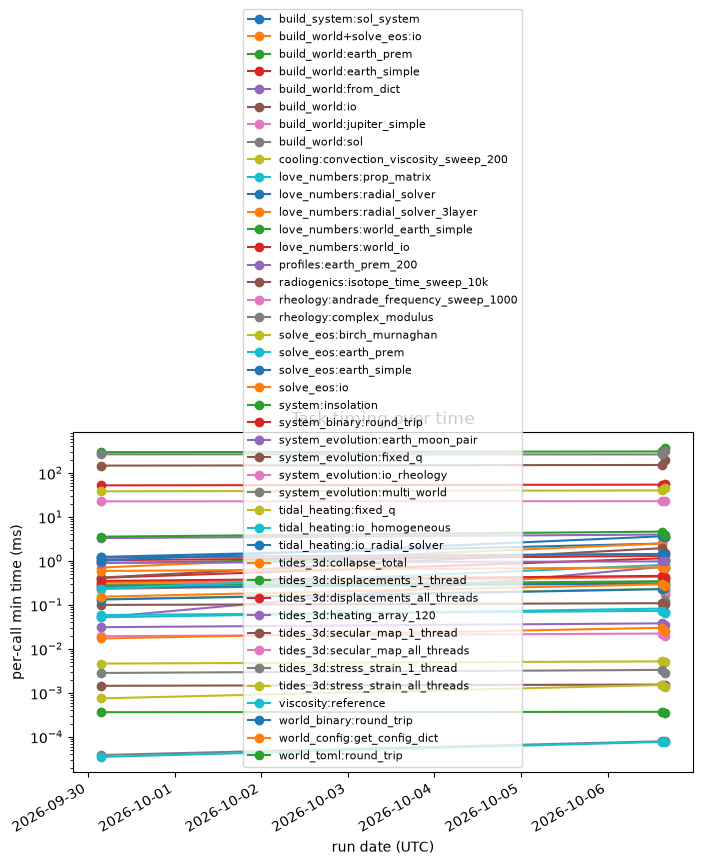

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
for name, g in df.sort_values("timestamp_utc").groupby("name"):
    ax.plot(g["timestamp_utc"], g["min_ms"], marker="o", label=name)
ax.set_xlabel("run date (UTC)")
ax.set_ylabel("per-call min time (ms)")
ax.set_yscale("log")
ax.set_title("Task timing over time")
ax.legend(fontsize=8, loc="best")
fig.autofmt_xdate()
plt.show()


## Timing by TidalPy Version

For each task, the latest recorded time under each TidalPy version, so one version can be compared against another.

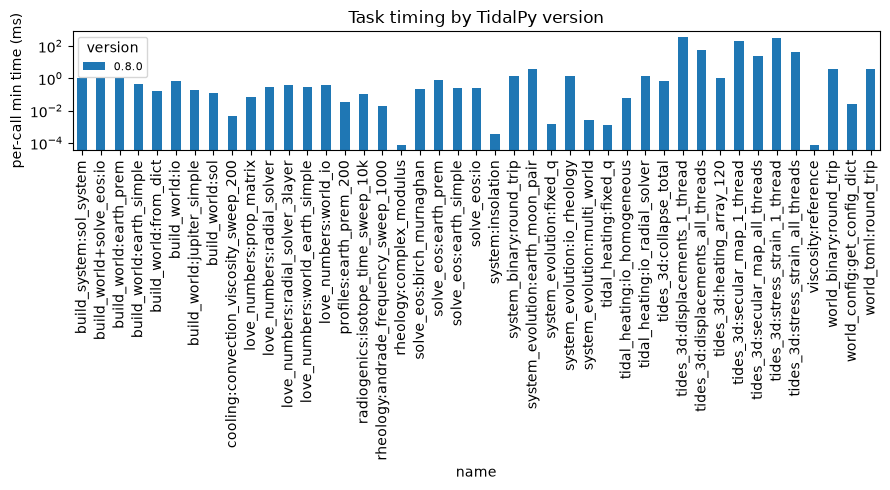

tidalpy_version,0.8.0
name,
build_system:sol_system,1.0566
build_world+solve_eos:io,1.0642
build_world:earth_prem,1.0713
build_world:earth_simple,0.4391
build_world:from_dict,0.1767
build_world:io,0.6722
build_world:jupiter_simple,0.1927
build_world:sol,0.1256
cooling:convection_viscosity_sweep_200,0.0049


In [4]:
by_version = (
    df.sort_values("timestamp_utc")
    .groupby(["name", "tidalpy_version"], as_index=False)
    .last()
    .pivot(index="name", columns="tidalpy_version", values="min_ms")
)
ax = by_version.plot.bar(figsize=(9, 5), logy=True)
ax.set_ylabel("per-call min time (ms)")
ax.set_title("Task timing by TidalPy version")
ax.legend(title="version", fontsize=8)
plt.tight_layout()
plt.show()
by_version.round(4)


## Timing by Machine

The latest time for each task on each machine, for comparing across OS and hardware.

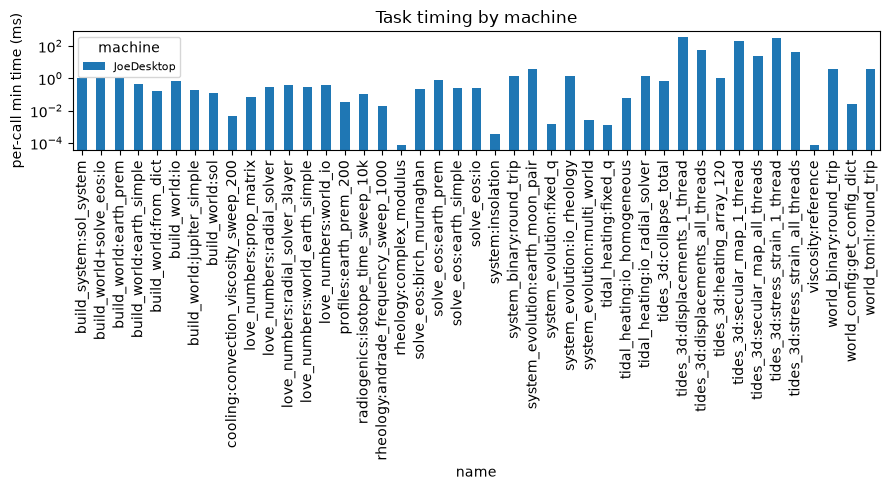

node,JoeDesktop
name,
build_system:sol_system,1.0566
build_world+solve_eos:io,1.0642
build_world:earth_prem,1.0713
build_world:earth_simple,0.4391
build_world:from_dict,0.1767
build_world:io,0.6722
build_world:jupiter_simple,0.1927
build_world:sol,0.1256
cooling:convection_viscosity_sweep_200,0.0049


In [5]:
by_node = (
    df.sort_values("timestamp_utc")
    .groupby(["name", "node"], as_index=False)
    .last()
    .pivot(index="name", columns="node", values="min_ms")
)
ax = by_node.plot.bar(figsize=(9, 5), logy=True)
ax.set_ylabel("per-call min time (ms)")
ax.set_title("Task timing by machine")
ax.legend(title="machine", fontsize=8)
plt.tight_layout()
plt.show()
by_node.round(4)
